# SHAP Performance Regimes
This notebook assembles a run-scoped regime analysis table for one XGBoost interpretable-model run, evaluates reduced SHAP representations, compares clustering behavior across performance groups, and inspects the selected cluster SHAP signatures for easy, medium, and hard trajectory outcomes.


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from data_modelling.prepared_data import load_prepared_data, prepare_single_target_model_data
from data_modelling.run_context import format_exported_model_label, get_exported_model_info, load_run_context
from data_modelling.shap_performance_regimes_utils import (
    TRUSTWORTHINESS_COLUMNS,
    assemble_step1_analysis_table,
    build_cluster_shap_profiles,
    build_shap_regime_artifact_names,
    build_shap_regime_export_layout,
    evaluate_umap_trustworthiness_by_group,
    format_shap_feature_name,
    get_shap_cols,
    load_or_initialize_shap_regime_manifest,
    merge_shap_regime_artifact_records,
    resolve_cluster_spec,
    resolve_inspection_config,
    resolve_raw_metric_col,
    resolve_shap_regime_export_context,
    run_step2_clustering,
    select_inspection_cluster_runs,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

MODEL_ID = 'xgboost'
RUN_NAME = 'nusc_mini_debug_tpp-11_Mar_2026_15_29_02'
EVAL_CSV_NAME = 'eval_epoch_5.csv'
TARGET_COL = None  # Optional override, e.g. 'ml_ade_log'
LOWER_IS_BETTER = True
PERFORMANCE_GROUP_COL = 'performance_group'

CLUSTER_SPEC = {
    'groups': ['easy', 'medium', 'hard'],
    'algorithms': ['hdbscan', 'optics'],
    'evaluate_umap_latent_space': True,
    # Set one integer for all groups or a dict like {'easy': 2, 'medium': 4, 'hard': 2}.
    'umap_selected_n_components': {'easy': 3, 'medium': 3, 'hard': 3},
    'trustworthiness_neighbor_values': [5, 10, 15],
    'cluster_umap_n_neighbors': 30,
    'cluster_umap_min_dist': 0.0,
    'viz_umap_n_neighbors': 15,
    'viz_umap_min_dist': 0.1,
    'random_state': 42,
    # Set one integer for all groups or a dict like {'easy': 6, 'medium': 12, 'hard': 6}.
    'min_cluster_size': 5,
    # Set one integer for all groups or a dict like {'easy': 6, 'medium': 12, 'hard': 6}.
    'min_samples': 5,
    'optics_cluster_method': 'xi',
    'optics_xi': 0.05,
    'distance_metric': 'euclidean',
}

INSPECTION_CONFIG = {
    'inspection_algorithm': 'hdbscan',
    'inspection_cluster_space': 'umap',
    'inspection_top_k_features': 8,
    'inspection_top_k_table': 3,
    'sort_cluster_profiles_by': 'cluster_size',
}

if MODEL_ID != 'xgboost':
    raise NotImplementedError("This notebook currently supports MODEL_ID='xgboost' only.")



## Resolve Run Context and Artifact Paths
**Purpose:** Tie every input and output to one exported modelling run and one joined-metrics file.<br>
**Inputs:** `MODEL_ID`, `RUN_NAME`, `EVAL_CSV_NAME`, optional `TARGET_COL`.<br>
**Outputs:** Resolved run metadata, source artifact paths, and result directories for this notebook run.<br>
**How to Verify:** Confirm the printed target, feature count, and source paths match the exported run you intend to inspect.


In [2]:
run_ctx = load_run_context(MODEL_ID, RUN_NAME, TARGET_COL)
manifest = run_ctx.manifest
target_col = run_ctx.target_col
feature_cols = run_ctx.feature_cols
exported_model_info = get_exported_model_info(manifest)
exported_model_label = format_exported_model_label(exported_model_info)
raw_metric_col = resolve_raw_metric_col(manifest, target_col)

PREPARED_DATA_PATH = Path('../../results/interpretable_model/prepared_data') / RUN_NAME / f'prepared_data_{raw_metric_col}.csv'
SHAP_VALUES_PATH = run_ctx.tables_dir / f'shap_values_{target_col}.csv'
JOINED_METRICS_PATH = Path('../../results/trajectory_prediction/trajectory_metrics_joined') / RUN_NAME / EVAL_CSV_NAME
SHAP_REGIME_RESULTS_ROOT = Path('../../results/interpretable_model/shap_performance_regimes')

required_paths = [
    ('prepared data export', PREPARED_DATA_PATH),
    ('SHAP value export', SHAP_VALUES_PATH),
    ('joined metrics export', JOINED_METRICS_PATH),
]
for label, path in required_paths:
    if not path.exists():
        raise FileNotFoundError(f'Missing required {label}: {path}')

print(f'Run: {RUN_NAME}')
print(f'Eval CSV: {EVAL_CSV_NAME}')
print(f'Exported model: {exported_model_label}')
print(f'Resolved target_col: {target_col}')
print(f'Resolved raw metric col: {raw_metric_col}')
print(f'Feature count: {len(feature_cols)}')
print(f'Prepared data path: {PREPARED_DATA_PATH}')
print(f'SHAP values path: {SHAP_VALUES_PATH}')
print(f'Joined metrics path: {JOINED_METRICS_PATH}')
print(f'SHAP regime export root: {SHAP_REGIME_RESULTS_ROOT.resolve()}')



Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Eval CSV: eval_epoch_5.csv
Exported model: XGBoost (xgboost, target_mode=log)
Resolved target_col: ml_ade_log
Resolved raw metric col: ml_ade
Feature count: 13
Prepared data path: ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
SHAP values path: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/shap_values_ml_ade_log.csv
Joined metrics path: ../../results/trajectory_prediction/trajectory_metrics_joined/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/eval_epoch_5.csv
SHAP regime export root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes


## Load the Prepared Modelling Table
**Purpose:** Reconstruct the exact modelling rows and feature key used by the interpretable model.<br>
**Inputs:** `PREPARED_DATA_PATH`, resolved `target_col`, resolved `raw_metric_col`, and manifest `feature_cols`.<br>
**Outputs:** `model_df` on the notebook's modelling rows plus a verified feature-key definition.<br>
**How to Verify:** Check that the prepared target and feature columns exactly match the run manifest and that the printed row count looks plausible.


In [3]:
prepared_df = load_prepared_data(
    PREPARED_DATA_PATH,
    display_fn=display,
    include_missing_summary=True,
    include_dtype_summary=True,
)

prepared = prepare_single_target_model_data(
    prepared_df,
    target_col=target_col,
    default_target=raw_metric_col,
)
model_df = prepared['model_df'].copy()
prepared_feature_cols = prepared['feature_cols']

if prepared['target_col'] != target_col:
    raise ValueError(f"Prepared target mismatch. expected={target_col}, actual={prepared['target_col']}")
if prepared_feature_cols != feature_cols:
    raise ValueError(
        'Prepared feature columns do not match the run manifest exactly. '
        f'expected={feature_cols}, actual={prepared_feature_cols}'
    )

print(f'Prepared modelling rows: {len(model_df)}')
print(f'Prepared feature key size: {len(prepared_feature_cols)}')


Dataset shape: (451, 14)
Columns:
['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE', 'ml_ade_log']


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,ml_ade_log
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.649643
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,28.392473,0.014650,0.005171,0.140704
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,40.892780,0.027456,0.012630,0.388765
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,28.355738,0.013004,0.005689,0.821990
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,28.309616,0.014190,0.005676,0.159340



Missing values per column:


,missing_count
max_speed,0
std_speed,0
mean_acceleration,0
mean_jerk,0
heading_change,0
has_collision,0
min_neighbor_distance,0
scene_num_agents,0
scene_bbox_area,0
scene_bbox_width,0



Column dtypes:


,dtype
max_speed,float64
std_speed,float64
mean_acceleration,float64
mean_jerk,float64
heading_change,float64
has_collision,float64
min_neighbor_distance,float64
scene_num_agents,float64
scene_bbox_area,float64
scene_bbox_width,float64


Prepared modelling rows: 451
Prepared feature key size: 13


## Assemble the Performance-Regime Table
**Purpose:** Join prepared rows, run-scoped metrics, and SHAP exports, then validate the clustering and inspection configuration against the loaded SHAP feature set.<br>
**Inputs:** `model_df`, `JOINED_METRICS_PATH`, `SHAP_VALUES_PATH`, `CLUSTER_SPEC`, and `INSPECTION_CONFIG`.<br>
**Outputs:** `analysis_df`, performance-group summaries, resolved notebook config, and the trustworthiness plot manifest.<br>
**How to Verify:** Confirm the join row counts, the detected SHAP feature count, and the resolved UMAP candidate dimensions before moving to reduced-space evaluation.


In [4]:
def build_trustworthiness_plot_titles(cluster_spec: dict[str, object]) -> dict[str, str]:
    plot_titles = {
        f'nn_{neighbor_value}': (
            'UMAP trustworthiness by reduced dimension and performance group '
            f'(n_neighbors={neighbor_value})'
        )
        for neighbor_value in cluster_spec['trustworthiness_neighbor_values']
    }
    neighbor_label = ', '.join(str(value) for value in cluster_spec['trustworthiness_neighbor_values'])
    plot_titles[cluster_spec['trustworthiness_mean_view']] = (
        'UMAP trustworthiness by reduced dimension and performance group '
        f'(mean over n_neighbors={neighbor_label})'
    )
    return plot_titles


joined_metrics_df = pd.read_csv(JOINED_METRICS_PATH)
shap_values_df = pd.read_csv(SHAP_VALUES_PATH)

analysis_df, group_summary_df = assemble_step1_analysis_table(
    prepared_model_df=model_df,
    joined_metrics_df=joined_metrics_df,
    shap_values_df=shap_values_df,
    feature_cols=feature_cols,
    target_col=target_col,
    performance_metric_col=raw_metric_col,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
)

shap_cols = get_shap_cols(analysis_df)
CLUSTER_SPEC_RESOLVED = resolve_cluster_spec(CLUSTER_SPEC, shap_cols=shap_cols)
INSPECTION_CONFIG_RESOLVED = resolve_inspection_config(
    INSPECTION_CONFIG,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
)
EXPORT_CONTEXT = resolve_shap_regime_export_context(
    model_id=MODEL_ID,
    run_name=RUN_NAME,
    target_col=target_col,
    eval_csv_name=EVAL_CSV_NAME,
    lower_is_better=LOWER_IS_BETTER,
    performance_group_col=PERFORMANCE_GROUP_COL,
    results_root=SHAP_REGIME_RESULTS_ROOT,
)
EXPORT_LAYOUT = build_shap_regime_export_layout(
    export_context=EXPORT_CONTEXT,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
)
ARTIFACT_NAMES = build_shap_regime_artifact_names(
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    inspection_config=INSPECTION_CONFIG_RESOLVED,
)
TABLES_DIR = EXPORT_LAYOUT['tables_dir']
PLOTS_DIR = EXPORT_LAYOUT['plots_dir']
# Each cluster-spec folder stores one manifest.json alongside tables/ and plots/.
EXPORT_MANIFEST_PATH = EXPORT_LAYOUT['manifest_path']

REGIME_ANALYSIS_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['regime_analysis']
PERFORMANCE_GROUP_SUMMARY_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['performance_group_summary']
UMAP_TRUSTWORTHINESS_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['umap_trustworthiness']
CLUSTER_SCORES_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_scores']
CLUSTER_ASSIGNMENTS_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_assignments']
CLUSTER_SHAP_PROFILES_PATH = TABLES_DIR / ARTIFACT_NAMES['tables']['cluster_shap_profiles']
RAW_ALGORITHM_GRID_PATH = PLOTS_DIR / ARTIFACT_NAMES['plots']['raw_algorithm_comparison_grid']
UMAP_ALGORITHM_GRID_PATH = PLOTS_DIR / ARTIFACT_NAMES['plots']['umap_algorithm_comparison_grid']

if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    UMAP_TRUSTWORTHINESS_PLOT_PATHS = {
        trustworthiness_view: PLOTS_DIR / plot_name
        for trustworthiness_view, plot_name in ARTIFACT_NAMES['plots']['umap_trustworthiness_curves'].items()
    }
    TRUSTWORTHINESS_PLOT_TITLES = build_trustworthiness_plot_titles(CLUSTER_SPEC_RESOLVED)
else:
    UMAP_TRUSTWORTHINESS_PLOT_PATHS = {}
    TRUSTWORTHINESS_PLOT_TITLES = {}

group_counts_df = (
    analysis_df[PERFORMANCE_GROUP_COL]
    .value_counts()
    .rename_axis(PERFORMANCE_GROUP_COL)
    .reset_index(name='count')
)

print(f'Joined metrics rows: {len(joined_metrics_df)}')
print(f'SHAP value rows: {len(shap_values_df)}')
print(f'Analysis rows: {len(analysis_df)}')
print(f'SHAP feature columns available: {len(shap_cols)}')
print(f"Resolved UMAP candidate dimensions: {CLUSTER_SPEC_RESOLVED['umap_candidate_dims']}")
print(
    'Inspection selection: '
    f"algorithm={INSPECTION_CONFIG_RESOLVED['inspection_algorithm']}, "
    f"space={INSPECTION_CONFIG_RESOLVED['inspection_cluster_space']}"
)
print(f"Cluster-spec export root: {EXPORT_LAYOUT['cluster_spec_root']}")
print(f"Export manifest path: {EXPORT_MANIFEST_PATH}")

display(group_summary_df)
display(group_counts_df)
display(analysis_df.head())



Joined metrics rows: 451
SHAP value rows: 451
Analysis rows: 451
SHAP feature columns available: 13
Resolved UMAP candidate dimensions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Inspection selection: algorithm=hdbscan, space=raw
Cluster-spec export root: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb22e137
Export manifest path: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_group/cluster_spec__groups-easy-medium-hard__algs-hdbscan-optics__umap-on__dims-easy3-hard3-medium3__a14cdb

,metric_col,q25,q75,n_total,n_easy,n_medium,n_hard,n_equal_q25,n_equal_q75
0,ml_ade,0.353661,1.079434,451,113,225,113,0,0


,performance_group,count
0,medium,225
1,easy,113
2,hard,113


,max_speed,std_speed,mean_acceleration,mean_jerk,heading_change,has_collision,min_neighbor_distance,scene_num_agents,scene_bbox_area,scene_bbox_width,...,shap__has_collision,shap__min_neighbor_distance,shap__scene_num_agents,shap__scene_bbox_area,shap__scene_bbox_width,shap__scene_bbox_height,shap__scene_spatial_density,shap__scene_density_VEHICLE,shap_base_value,performance_group
0,1.230403,0.116722,0.056417,0.490805,112.440745,0.0,1.013903,17.0,1160.377375,40.869190,...,0.001430,-0.035135,0.001324,-0.026313,-0.004604,-0.005327,-0.015913,-0.000752,0.548927,medium
1,0.218477,0.063105,0.007725,0.490449,941.304051,0.0,3.023524,17.0,1160.377375,40.869190,...,0.001301,0.006365,0.000971,-0.010948,-0.003711,0.002154,-0.001923,-0.005747,0.548927,easy
2,0.383437,0.099171,0.031384,0.401269,488.173829,0.0,1.104355,50.0,1821.083675,44.533135,...,0.001971,-0.003065,-0.008558,0.008346,-0.007160,-0.005434,-0.062172,0.005455,0.548927,medium
3,1.483624,0.190256,0.051802,0.879107,81.155053,1.0,0.426945,16.0,1230.401053,43.391608,...,-0.000916,-0.046982,-0.004607,0.002888,0.000848,-0.002933,0.080973,0.004454,0.548927,hard
4,0.218477,0.064457,0.010995,0.483671,946.683531,0.0,2.796330,15.0,1057.088774,37.340273,...,0.001115,0.004643,0.002131,-0.010526,-0.023480,-0.008097,0.008853,0.000660,0.548927,easy


## Evaluate Reduced Representations
**Purpose:** Compute trustworthiness scores for dimensions `1, 2, ..., (#features - 1)` for each performance group and highlight the configured reduced dimension used for clustering.<br>
**Inputs:** `analysis_df`, resolved `CLUSTER_SPEC_RESOLVED`, `PERFORMANCE_GROUP_COL`, and `shap_cols`.<br>
**Outputs:** `trustworthiness_df` and one trustworthiness curve per configured neighborhood view when reduced-space evaluation is enabled.<br>
**How to Verify:** Check that every performance group appears in the trustworthiness curves and that the highlighted points match `CLUSTER_SPEC['umap_selected_n_components']`.


/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/

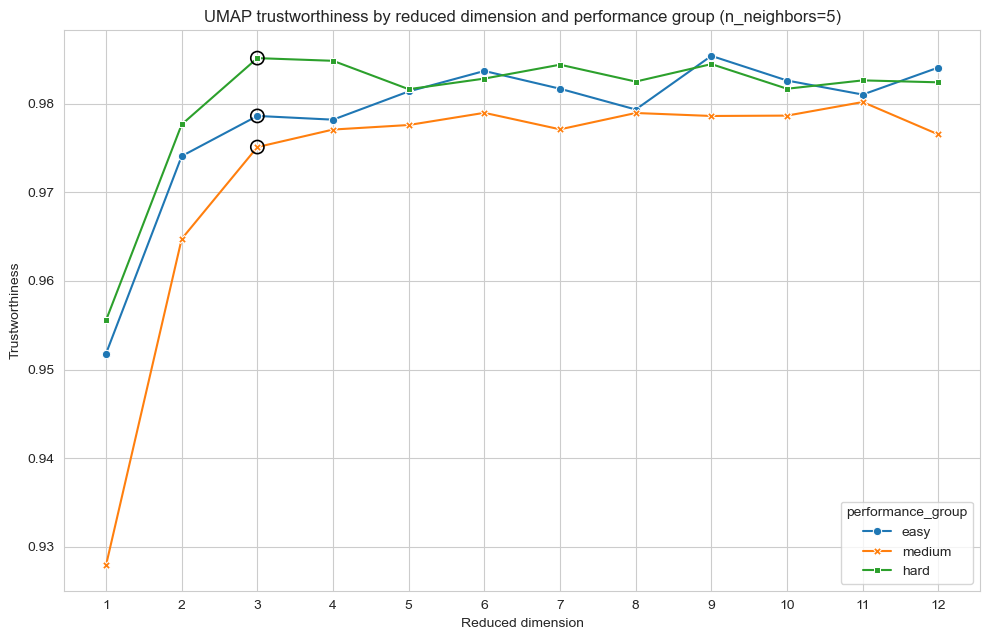

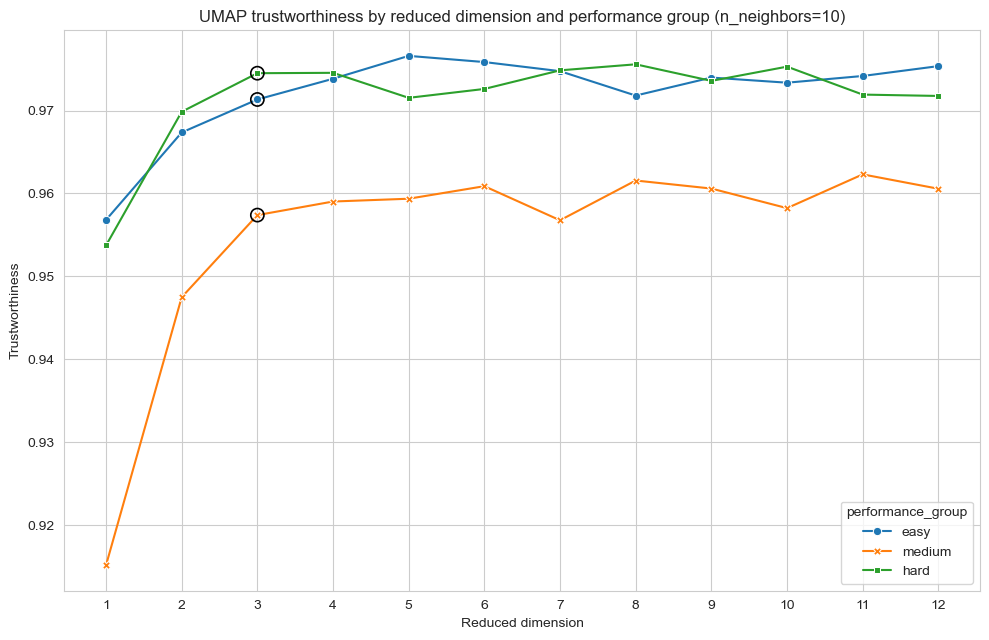

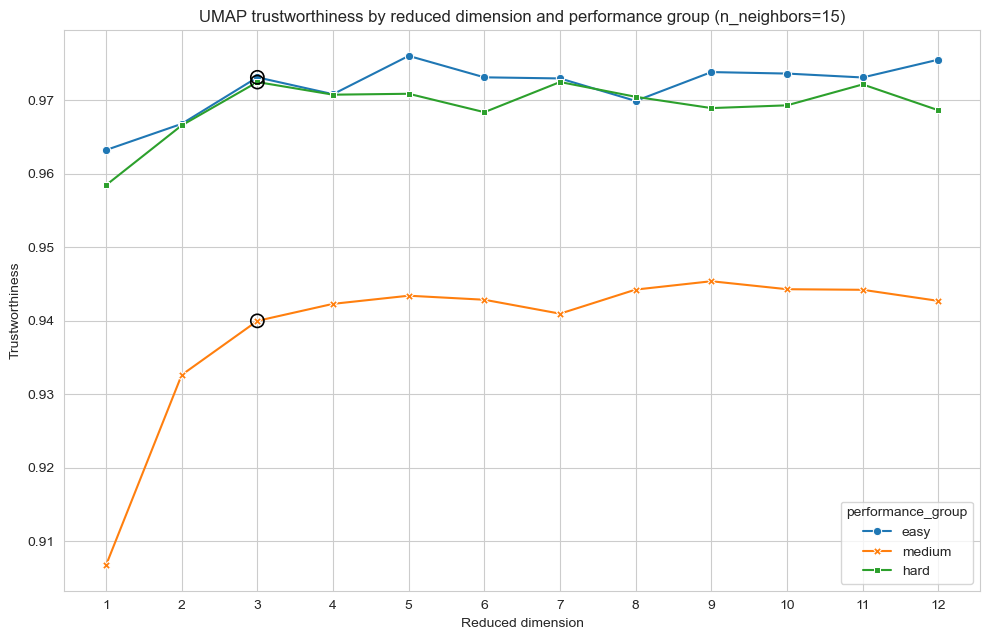

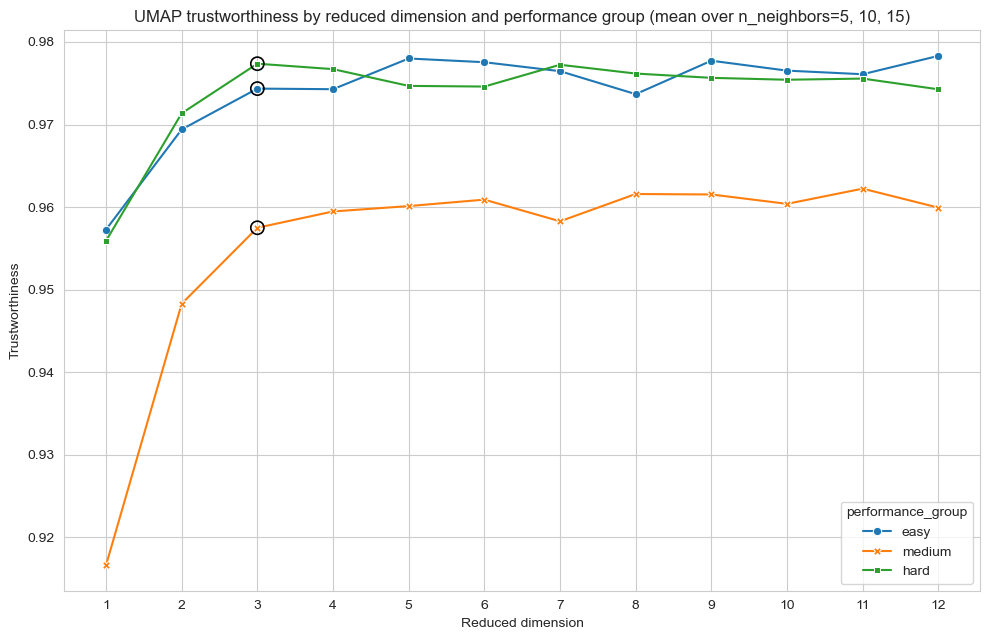

If the highlighted dimensions do not match your intended clustering setup, update CLUSTER_SPEC['umap_selected_n_components'] and rerun from the previous section.


,performance_group,n_components,trustworthiness_view,trustworthiness_n_neighbors,trustworthiness,selected_for_clustering
0,easy,1,nn_5,5,0.951791,False
1,easy,1,nn_10,10,0.956814,False
2,easy,1,nn_15,15,0.963232,False
3,easy,1,mean_5_10_15,<NA>,0.957279,False
4,easy,2,nn_5,5,0.974075,False
...,...,...,...,...,...,...
139,hard,11,mean_5_10_15,<NA>,0.975564,False
140,hard,12,nn_5,5,0.982402,False
141,hard,12,nn_10,10,0.971754,False
142,hard,12,nn_15,15,0.968640,False


In [5]:
def plot_trustworthiness_curves(
    trustworthiness_df: pd.DataFrame,
    *,
    plot_titles: dict[str, str],
    plot_paths: dict[str, Path],
) -> None:
    for trustworthiness_view, plot_title in plot_titles.items():
        plot_df = trustworthiness_df.loc[
            trustworthiness_df['trustworthiness_view'] == trustworthiness_view
        ].copy()
        if plot_df.empty:
            raise ValueError(f'Missing trustworthiness rows for view={trustworthiness_view!r}.')

        fig, ax = plt.subplots(figsize=(10, 6.5))
        sns.lineplot(
            data=plot_df,
            x='n_components',
            y='trustworthiness',
            hue='performance_group',
            style='performance_group',
            markers=True,
            dashes=False,
            ax=ax,
        )
        selected_points_df = plot_df.loc[plot_df['selected_for_clustering']].copy()
        if not selected_points_df.empty:
            ax.scatter(
                selected_points_df['n_components'],
                selected_points_df['trustworthiness'],
                s=90,
                facecolors='none',
                edgecolors='black',
                linewidths=1.2,
                zorder=5,
            )
        ax.set_title(plot_title)
        ax.set_xlabel('Reduced dimension')
        ax.set_ylabel('Trustworthiness')
        ax.set_xticks(sorted(plot_df['n_components'].unique().tolist()))
        plt.tight_layout()
        plt.savefig(plot_paths[trustworthiness_view], dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)


if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    trustworthiness_df = evaluate_umap_trustworthiness_by_group(
        analysis_df,
        cluster_spec=CLUSTER_SPEC_RESOLVED,
        performance_group_col=PERFORMANCE_GROUP_COL,
        shap_cols=shap_cols,
    )
    plot_trustworthiness_curves(
        trustworthiness_df,
        plot_titles=TRUSTWORTHINESS_PLOT_TITLES,
        plot_paths=UMAP_TRUSTWORTHINESS_PLOT_PATHS,
    )
    print(
        "If the highlighted dimensions do not match your intended clustering setup, "
        "update CLUSTER_SPEC['umap_selected_n_components'] and rerun from the previous section."
    )
else:
    trustworthiness_df = pd.DataFrame(columns=TRUSTWORTHINESS_COLUMNS)
    print("Skipped reduced-space trustworthiness evaluation because CLUSTER_SPEC['evaluate_umap_latent_space']=False.")

display(trustworthiness_df)


## Cluster Within Performance Groups
**Purpose:** Cluster SHAP vectors separately inside each performance group, then resolve the inspected cluster run from the validated inspection config.<br>
**Inputs:** `analysis_df`, resolved `CLUSTER_SPEC_RESOLVED`, resolved `INSPECTION_CONFIG_RESOLVED`, `PERFORMANCE_GROUP_COL`, and `shap_cols`.<br>
**Outputs:** Cluster assignments, scored clustering runs, the notebook's selected inspection runs, and cluster-level SHAP profile tables.<br>
**How to Verify:** Confirm that each performance group has scored cluster runs and that the inspected run table matches the requested algorithm and cluster space.


In [6]:
clustering_results = run_step2_clustering(
    analysis_df,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    performance_group_col=PERFORMANCE_GROUP_COL,
    row_id_col='row_id',
    shap_cols=shap_cols,
)

clustered_df = clustering_results['clustered_df']
cluster_scores_df = clustering_results['cluster_scores_df']
best_cluster_runs_df = cluster_scores_df.loc[cluster_scores_df['selected_for_group']].copy()
inspected_cluster_runs_df = select_inspection_cluster_runs(
    cluster_scores_df,
    cluster_spec=CLUSTER_SPEC_RESOLVED,
    inspection_config=INSPECTION_CONFIG_RESOLVED,
)
cluster_shap_profiles_df = build_cluster_shap_profiles(
    clustered_df,
    inspected_cluster_runs_df,
    performance_group_col=PERFORMANCE_GROUP_COL,
    shap_cols=shap_cols,
)

print(f'Cluster score rows: {len(cluster_scores_df)}')
print(f'Best-ranked regime runs: {len(best_cluster_runs_df)}')
print(
    'Inspection selection: '
    f"algorithm={INSPECTION_CONFIG_RESOLVED['inspection_algorithm']}, "
    f"space={INSPECTION_CONFIG_RESOLVED['inspection_cluster_space']}, "
    f'groups={len(inspected_cluster_runs_df)}'
)
print(f'Cluster profile rows: {len(cluster_shap_profiles_df)}')

display(cluster_scores_df)
display(best_cluster_runs_df)
display(inspected_cluster_runs_df)
display(cluster_shap_profiles_df.head())


/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/adaptive-py310/lib/python3.10/

Cluster score rows: 12
Best-ranked regime runs: 3
Inspection selection: algorithm=hdbscan, space=raw, groups=3
Cluster profile rows: 8


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_shap_space,valid_for_selection,valid_for_raw_shap_evaluation,selected_for_group
2,2,easy,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,3,0,0.000000,1.000000,0.742153,0.742153,-0.046095,True,True,True
3,3,easy,optics,umap,cluster_optics_umap,3,113,5,5,0.05,...,10,46,0.407080,0.592920,0.343378,0.343378,0.132458,True,True,False
0,0,easy,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,2,3,0.026549,0.973451,0.336254,0.336254,0.336254,True,True,False
1,1,easy,optics,raw,cluster_optics_raw,13,113,5,5,0.05,...,6,66,0.584071,0.415929,0.119600,0.119600,0.119600,True,True,False
10,10,hard,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,2,0,0.000000,1.000000,0.877322,0.877322,0.081726,True,True,True
11,11,hard,optics,umap,cluster_optics_umap,3,113,5,5,0.05,...,11,32,0.283186,0.716814,0.387628,0.387628,0.143106,True,True,False
9,9,hard,optics,raw,cluster_optics_raw,13,113,5,5,0.05,...,8,62,0.548673,0.451327,0.196297,0.196297,0.196297,True,True,False
8,8,hard,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,4,31,0.274336,0.725664,0.181171,0.181171,0.181171,True,True,False
7,7,medium,optics,umap,cluster_optics_umap,3,225,5,5,0.05,...,20,49,0.217778,0.782222,0.336255,0.336255,0.013483,True,True,True
6,6,medium,hdbscan,umap,cluster_hdbscan_umap,3,225,5,5,NaN,...,10,30,0.133333,0.866667,0.336148,0.336148,-0.093443,True,True,False


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_shap_space,valid_for_selection,valid_for_raw_shap_evaluation,selected_for_group
2,2,easy,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,3,0,0.000000,1.000000,0.742153,0.742153,-0.046095,True,True,True
10,10,hard,hdbscan,umap,cluster_hdbscan_umap,3,113,5,5,NaN,...,2,0,0.000000,1.000000,0.877322,0.877322,0.081726,True,True,True
7,7,medium,optics,umap,cluster_optics_umap,3,225,5,5,0.05,...,20,49,0.217778,0.782222,0.336255,0.336255,0.013483,True,True,True


,score_row_id,performance_group,algorithm,cluster_space,candidate_label_col,input_dim,group_size,min_cluster_size,min_samples,optics_xi,...,n_clusters,noise_count,noise_fraction,clustered_fraction,dbcv,dbcv_cluster_space,dbcv_raw_shap_space,valid_for_selection,valid_for_raw_shap_evaluation,selected_for_group
0,0,easy,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,2,3,0.026549,0.973451,0.336254,0.336254,0.336254,True,True,False
8,8,hard,hdbscan,raw,cluster_hdbscan_raw,13,113,5,5,NaN,...,4,31,0.274336,0.725664,0.181171,0.181171,0.181171,True,True,False
4,4,medium,hdbscan,raw,cluster_hdbscan_raw,13,225,5,5,NaN,...,2,51,0.226667,0.773333,0.029007,0.029007,0.029007,True,True,False


,performance_group,selected_algorithm,selected_cluster_space,cluster_id,cluster_size,cluster_size_share,shap__max_speed,shap__std_speed,shap__mean_acceleration,shap__mean_jerk,...,cluster_rank_by_size,dominant_feature_1,dominant_abs_shap_1,dominant_direction_1,dominant_feature_2,dominant_abs_shap_2,dominant_direction_2,dominant_feature_3,dominant_abs_shap_3,dominant_direction_3
0,easy,hdbscan,raw,1,62,0.548673,-0.232887,-0.105563,-0.001769,-0.010578,...,1,max_speed,0.232887,negative,std_speed,0.105563,negative,scene_spatial_density,0.040771,negative
1,easy,hdbscan,raw,0,48,0.424779,0.017895,-0.079982,-0.021311,-0.041925,...,2,heading_change,0.093504,negative,std_speed,0.079982,negative,mean_jerk,0.041925,negative
2,hard,hdbscan,raw,1,34,0.300885,0.108240,-0.028998,0.043583,0.036348,...,1,max_speed,0.108240,positive,min_neighbor_distance,0.047354,positive,mean_acceleration,0.043583,positive
3,hard,hdbscan,raw,3,32,0.283186,0.091921,0.081644,0.021878,0.000724,...,2,heading_change,0.152190,positive,max_speed,0.091921,positive,std_speed,0.081644,positive
4,hard,hdbscan,raw,0,10,0.088496,0.081132,0.297476,-0.060394,0.077237,...,3,std_speed,0.297476,positive,heading_change,0.139066,positive,max_speed,0.081132,positive


## Compare Clustering Outputs
**Purpose:** Show one panel per `(performance group, clustering algorithm)` combination for raw SHAP and, when enabled, reduced SHAP spaces.<br>
**Inputs:** `cluster_scores_df`, `clustered_df`, resolved `CLUSTER_SPEC_RESOLVED`, and the shared visualization embedding stored in `clustered_df`.<br>
**Outputs:** Saved comparison grids plus compact summary tables for the raw and reduced clustering runs.<br>
**How to Verify:** Confirm that each visible panel uses the expected performance group and algorithm and that the DBCV and cluster-count annotations line up with `cluster_scores_df`.


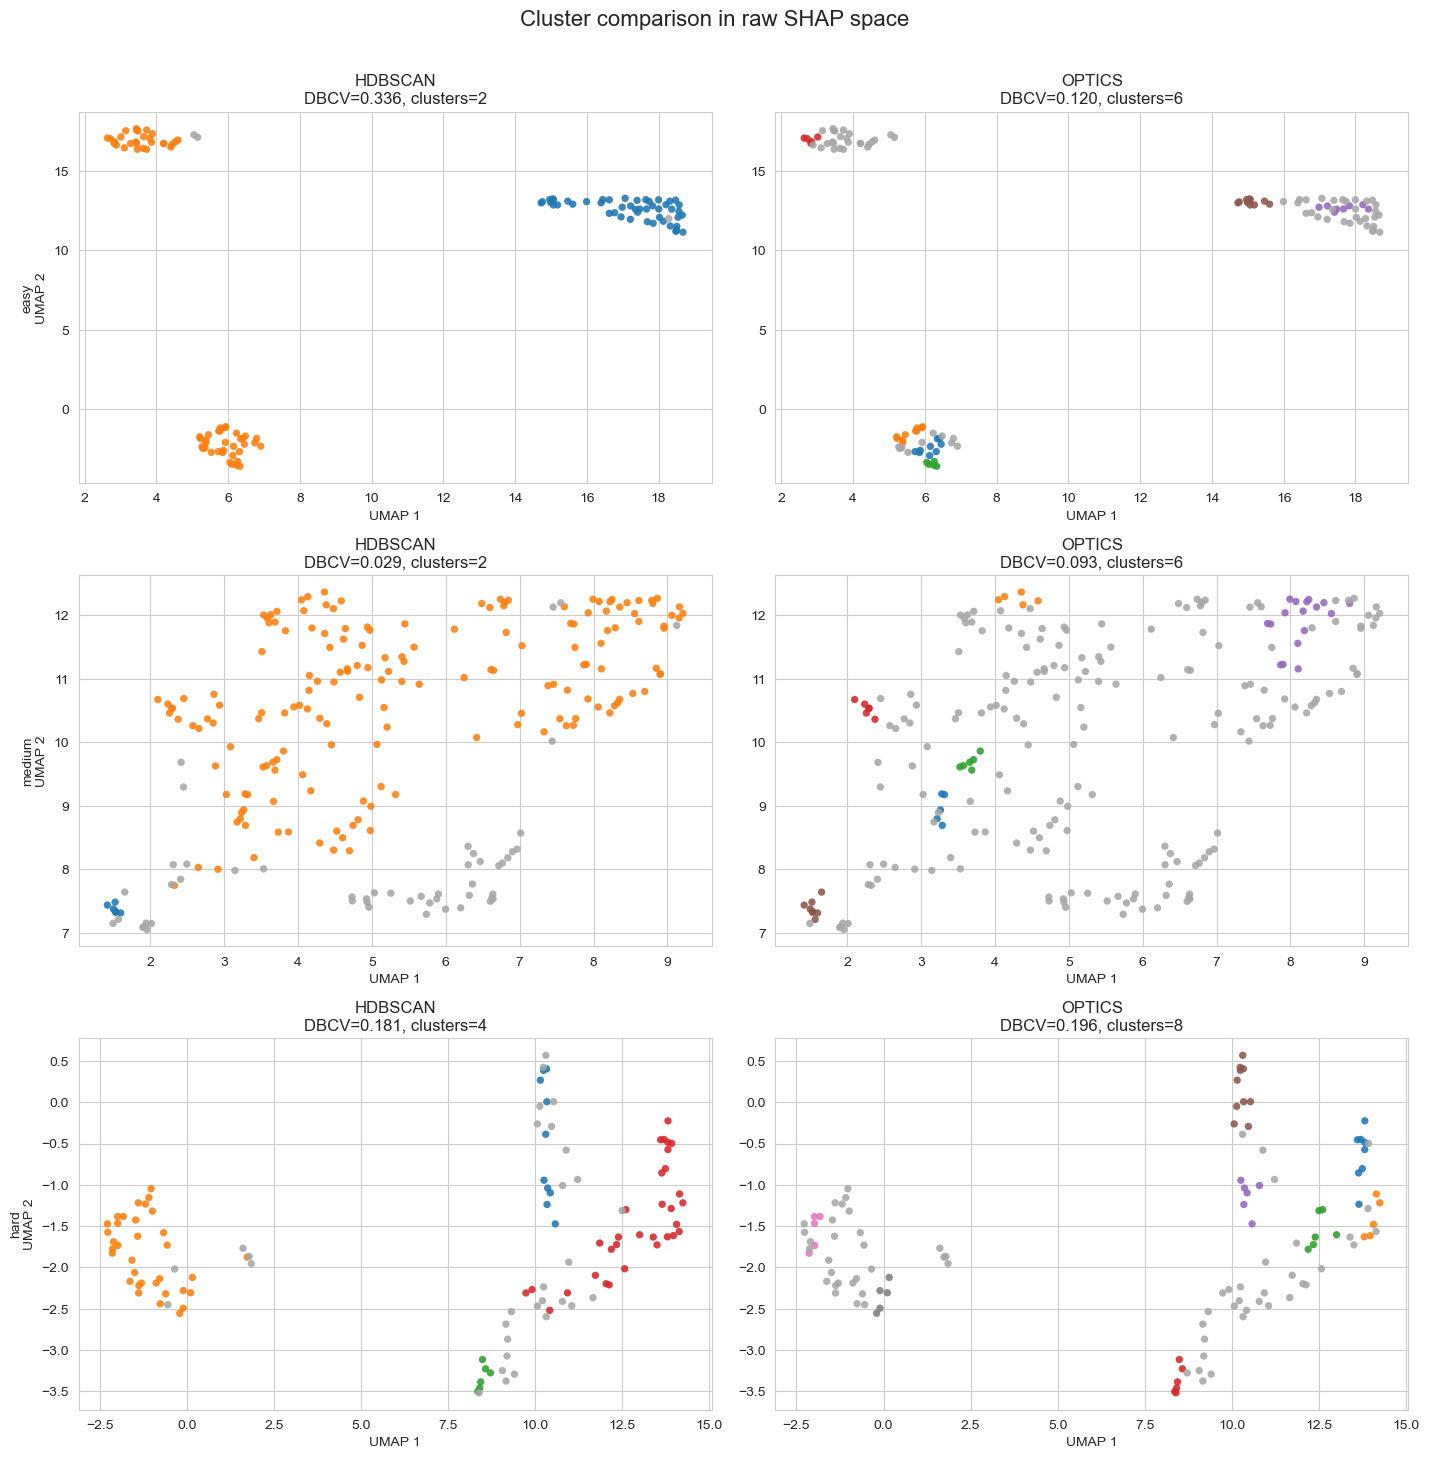

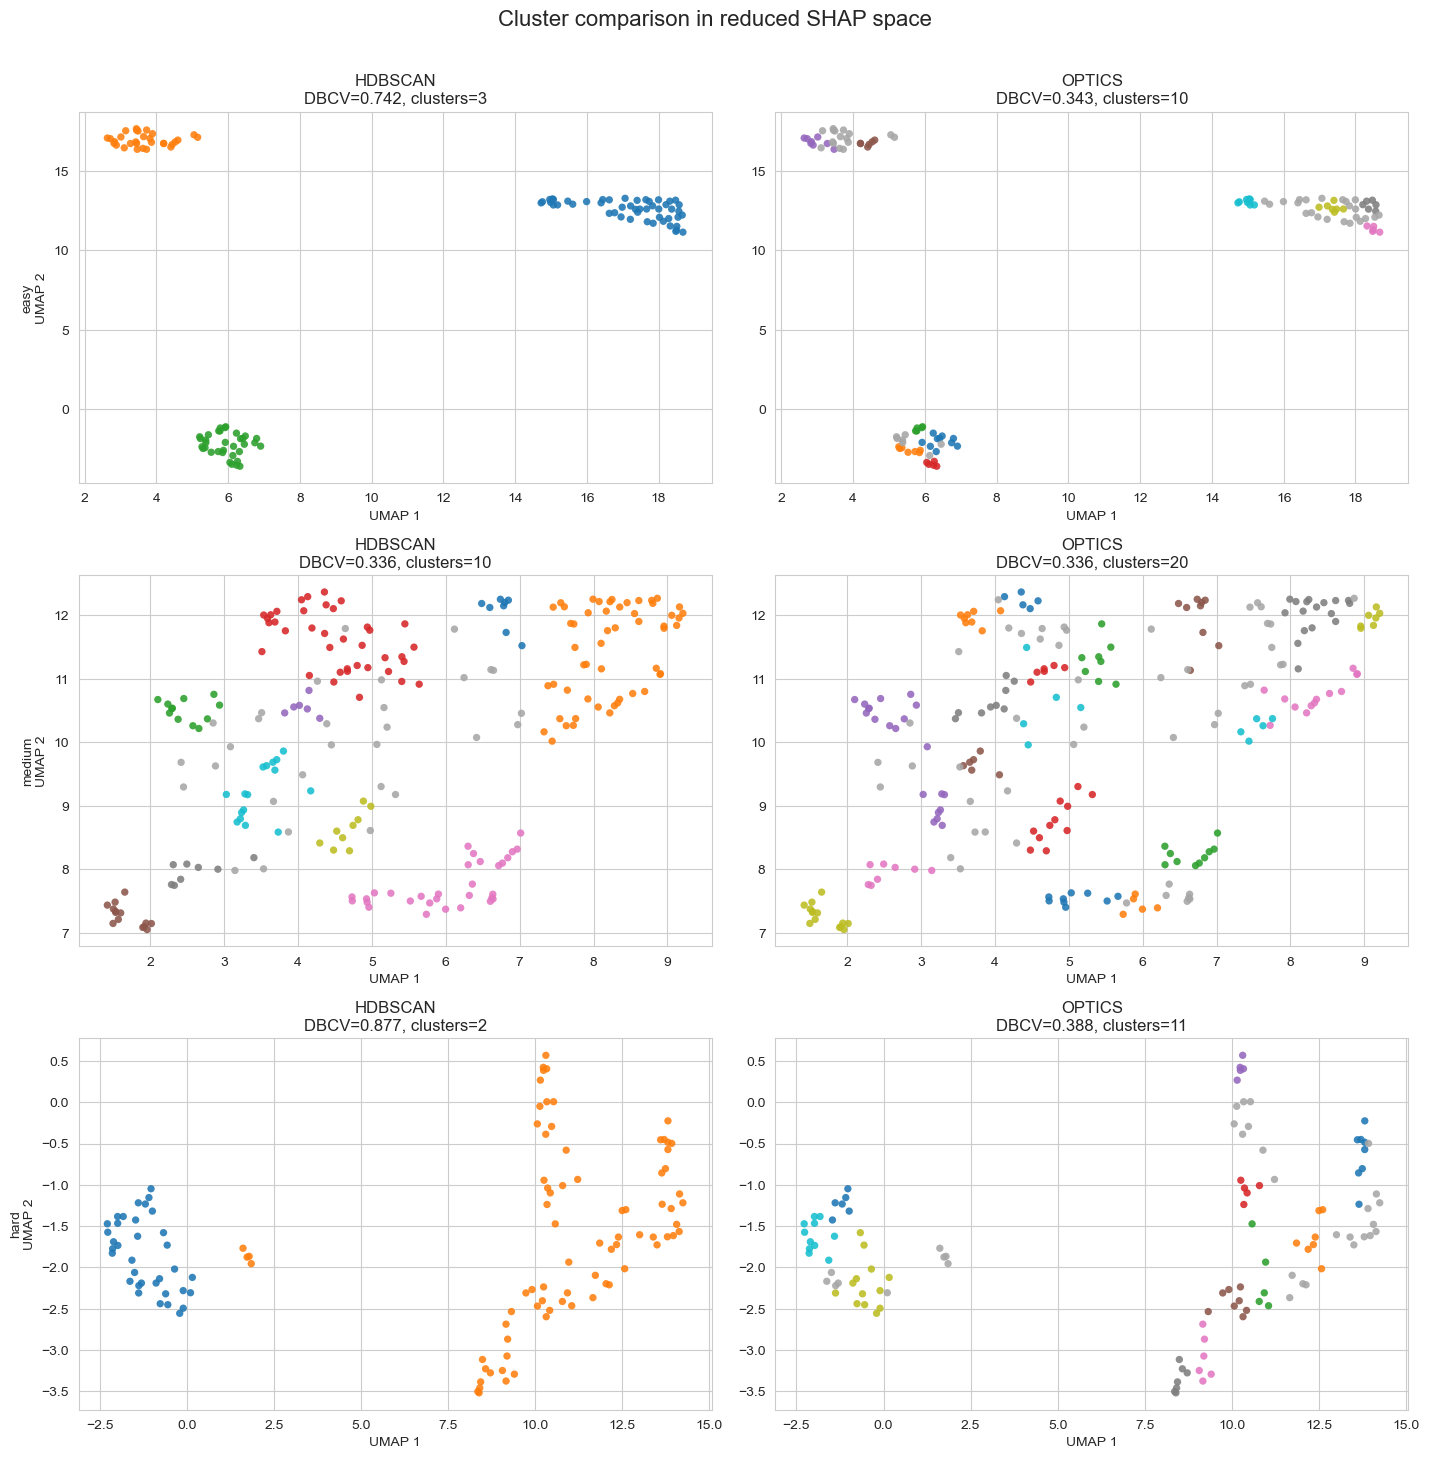

Raw-space clustering runs:


,performance_group,algorithm,cluster_space,dbcv_raw_shap_space,n_clusters,noise_fraction
0,easy,hdbscan,raw,0.336254,2,0.026549
1,easy,optics,raw,0.119600,6,0.584071
2,hard,hdbscan,raw,0.181171,4,0.274336
3,hard,optics,raw,0.196297,8,0.548673
4,medium,hdbscan,raw,0.029007,2,0.226667
5,medium,optics,raw,0.092911,6,0.791111


Reduced-space clustering runs:


,performance_group,algorithm,cluster_space,dbcv_raw_shap_space,n_clusters,noise_fraction
0,easy,hdbscan,umap,-0.046095,3,0.000000
1,easy,optics,umap,0.132458,10,0.407080
2,hard,hdbscan,umap,0.081726,2,0.000000
3,hard,optics,umap,0.143106,11,0.283186
4,medium,hdbscan,umap,-0.093443,10,0.133333
5,medium,optics,umap,0.013483,20,0.217778


In [7]:
def plot_cluster_comparison_grid(
    cluster_scores_subset: pd.DataFrame,
    *,
    plot_path: Path,
    cluster_space_label: str,
) -> pd.DataFrame:
    groups = CLUSTER_SPEC_RESOLVED['groups']
    algorithms = CLUSTER_SPEC_RESOLVED['algorithms']
    comparison_df = cluster_scores_subset.copy()
    fig, axes = plt.subplots(
        len(groups),
        len(algorithms),
        figsize=(7.2 * len(algorithms), 4.8 * len(groups)),
        squeeze=False,
    )

    for row_idx, performance_group in enumerate(groups):
        for col_idx, algorithm in enumerate(algorithms):
            ax = axes[row_idx][col_idx]
            selected_rows = comparison_df.loc[
                (comparison_df['performance_group'] == performance_group)
                & (comparison_df['algorithm'] == algorithm)
            ]
            if selected_rows.empty:
                ax.set_visible(False)
                continue

            comparison_row = selected_rows.iloc[0]
            group_df = clustered_df.loc[clustered_df[PERFORMANCE_GROUP_COL] == performance_group].copy()
            label_col = comparison_row['candidate_label_col']
            cluster_ids = [
                int(cluster_id)
                for cluster_id in group_df[label_col].dropna().astype(int).unique().tolist()
            ]
            ordered_cluster_ids = sorted(cluster_id for cluster_id in cluster_ids if cluster_id != -1)
            if -1 in cluster_ids:
                ordered_cluster_ids.append(-1)

            palette = sns.color_palette(
                'tab10',
                n_colors=max(len(ordered_cluster_ids) - (1 if -1 in ordered_cluster_ids else 0), 1),
            )
            color_lookup = {
                cluster_id: palette[idx % len(palette)]
                for idx, cluster_id in enumerate(
                    cluster_id for cluster_id in ordered_cluster_ids if cluster_id != -1
                )
            }
            if -1 in ordered_cluster_ids:
                color_lookup[-1] = (0.65, 0.65, 0.65)

            for cluster_id in ordered_cluster_ids:
                cluster_rows = group_df.loc[group_df[label_col].astype('Int64') == cluster_id]
                ax.scatter(
                    cluster_rows['viz_umap_x'],
                    cluster_rows['viz_umap_y'],
                    s=28,
                    alpha=0.88,
                    c=[color_lookup[cluster_id]],
                    edgecolors='none',
                )

            dbcv_cluster_space = comparison_row['dbcv_cluster_space']
            dbcv_cluster_label = f'{dbcv_cluster_space:.3f}' if pd.notna(dbcv_cluster_space) else 'NaN'
            panel_title = (
                f"{algorithm.upper()}\n"
                f"DBCV={dbcv_cluster_label}, clusters={int(comparison_row['n_clusters'])}"
            )
            ax.set_title(panel_title)
            ax.set_xlabel('UMAP 1')
            if col_idx == 0:
                ax.set_ylabel(f'{performance_group}\nUMAP 2')
            else:
                ax.set_ylabel('')

    fig.suptitle(f'Cluster comparison in {cluster_space_label} space', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return comparison_df


raw_comparison_df = (
    cluster_scores_df.loc[cluster_scores_df['cluster_space'] == 'raw']
    .copy()
    .sort_values(['performance_group', 'algorithm'])
    .reset_index(drop=True)
)
plot_cluster_comparison_grid(
    raw_comparison_df,
    plot_path=RAW_ALGORITHM_GRID_PATH,
    cluster_space_label='raw SHAP',
)

if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    umap_comparison_df = (
        cluster_scores_df.loc[cluster_scores_df['cluster_space'] == 'umap']
        .copy()
        .sort_values(['performance_group', 'algorithm'])
        .reset_index(drop=True)
    )
    if umap_comparison_df.empty:
        raise ValueError(
            'Reduced-space clustering results are not available even though '
            "CLUSTER_SPEC['evaluate_umap_latent_space']=True."
        )
    plot_cluster_comparison_grid(
        umap_comparison_df,
        plot_path=UMAP_ALGORITHM_GRID_PATH,
        cluster_space_label='reduced SHAP',
    )
else:
    umap_comparison_df = pd.DataFrame(columns=cluster_scores_df.columns)
    print("Reduced-space comparison grid skipped because CLUSTER_SPEC['evaluate_umap_latent_space']=False.")

print('Raw-space clustering runs:')
display(
    raw_comparison_df[
        ['performance_group', 'algorithm', 'cluster_space', 'dbcv_raw_shap_space', 'n_clusters', 'noise_fraction']
    ]
)
print('Reduced-space clustering runs:')
display(
    umap_comparison_df[
        ['performance_group', 'algorithm', 'cluster_space', 'dbcv_raw_shap_space', 'n_clusters', 'noise_fraction']
    ]
)


## Inspect Regime SHAP Signatures
**Purpose:** Inspect the validated clustering variant for each performance group with compact top-driver tables, signed SHAP bar plots, and full cluster-profile heatmaps.<br>
**Inputs:** `cluster_shap_profiles_df`, `inspected_cluster_runs_df`, resolved `INSPECTION_CONFIG_RESOLVED`, and `shap_cols`.<br>
**Outputs:** Examiner-facing cluster summaries plus one bar plot and one heatmap per inspected performance group.<br>
**How to Verify:** Confirm that the dominant-feature tables, bar plots, and heatmaps agree on which features drive each cluster and that the plot titles show the configured algorithm and cluster space.


Inspection profile: easy


,performance_group,inspection_algorithm,inspection_cluster_space,dbcv_raw_shap_space,noise_fraction,n_clusters
0,easy,hdbscan,raw,0.336254,0.026549,2


,cluster_id,cluster_size,cluster_size_share,dominant_feature_1,dominant_direction_1,dominant_abs_shap_1,dominant_feature_2,dominant_direction_2,dominant_abs_shap_2,dominant_feature_3,dominant_direction_3,dominant_abs_shap_3
0,1,62,0.5487,max_speed,negative,0.2329,std_speed,negative,0.1056,scene_spatial_density,negative,0.0408
1,0,48,0.4248,heading_change,negative,0.0935,std_speed,negative,0.0800,mean_jerk,negative,0.0419


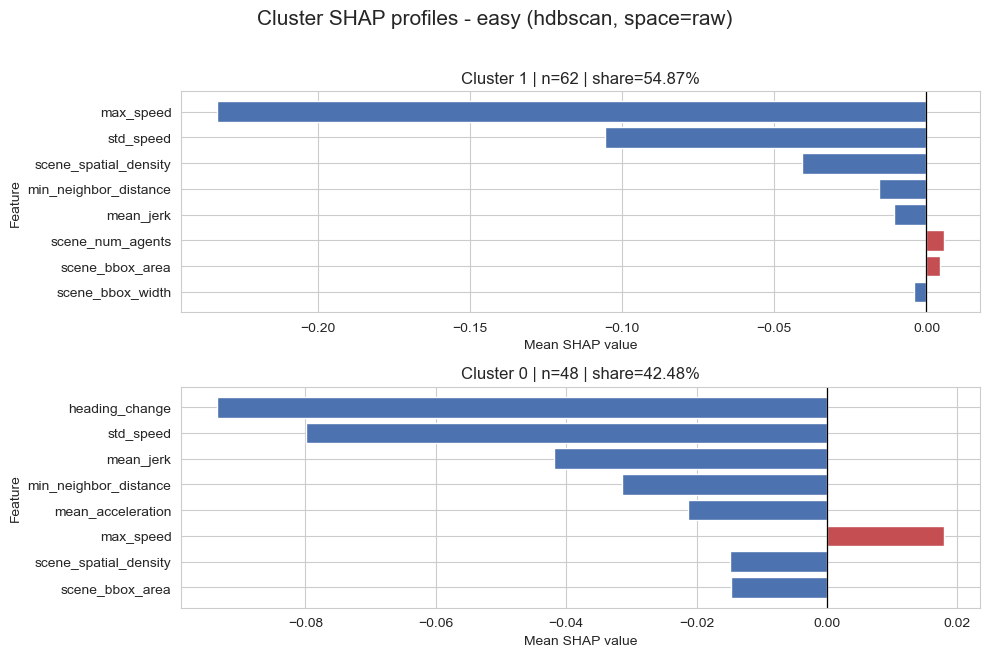

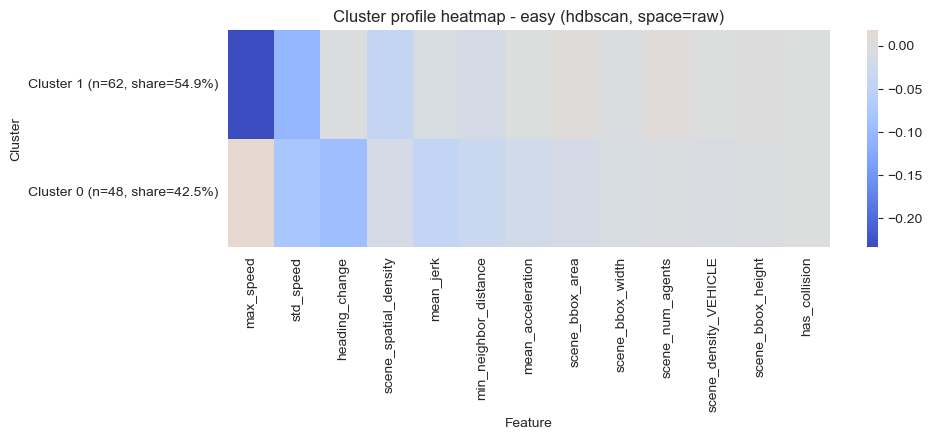

Inspection profile: hard


,performance_group,inspection_algorithm,inspection_cluster_space,dbcv_raw_shap_space,noise_fraction,n_clusters
0,hard,hdbscan,raw,0.181171,0.274336,4


,cluster_id,cluster_size,cluster_size_share,dominant_feature_1,dominant_direction_1,dominant_abs_shap_1,dominant_feature_2,dominant_direction_2,dominant_abs_shap_2,dominant_feature_3,dominant_direction_3,dominant_abs_shap_3
0,1,34,0.3009,max_speed,positive,0.1082,min_neighbor_distance,positive,0.0474,mean_acceleration,positive,0.0436
1,3,32,0.2832,heading_change,positive,0.1522,max_speed,positive,0.0919,std_speed,positive,0.0816
2,0,10,0.0885,std_speed,positive,0.2975,heading_change,positive,0.1391,max_speed,positive,0.0811
3,2,6,0.0531,std_speed,positive,0.1394,heading_change,positive,0.0950,scene_spatial_density,negative,0.0603


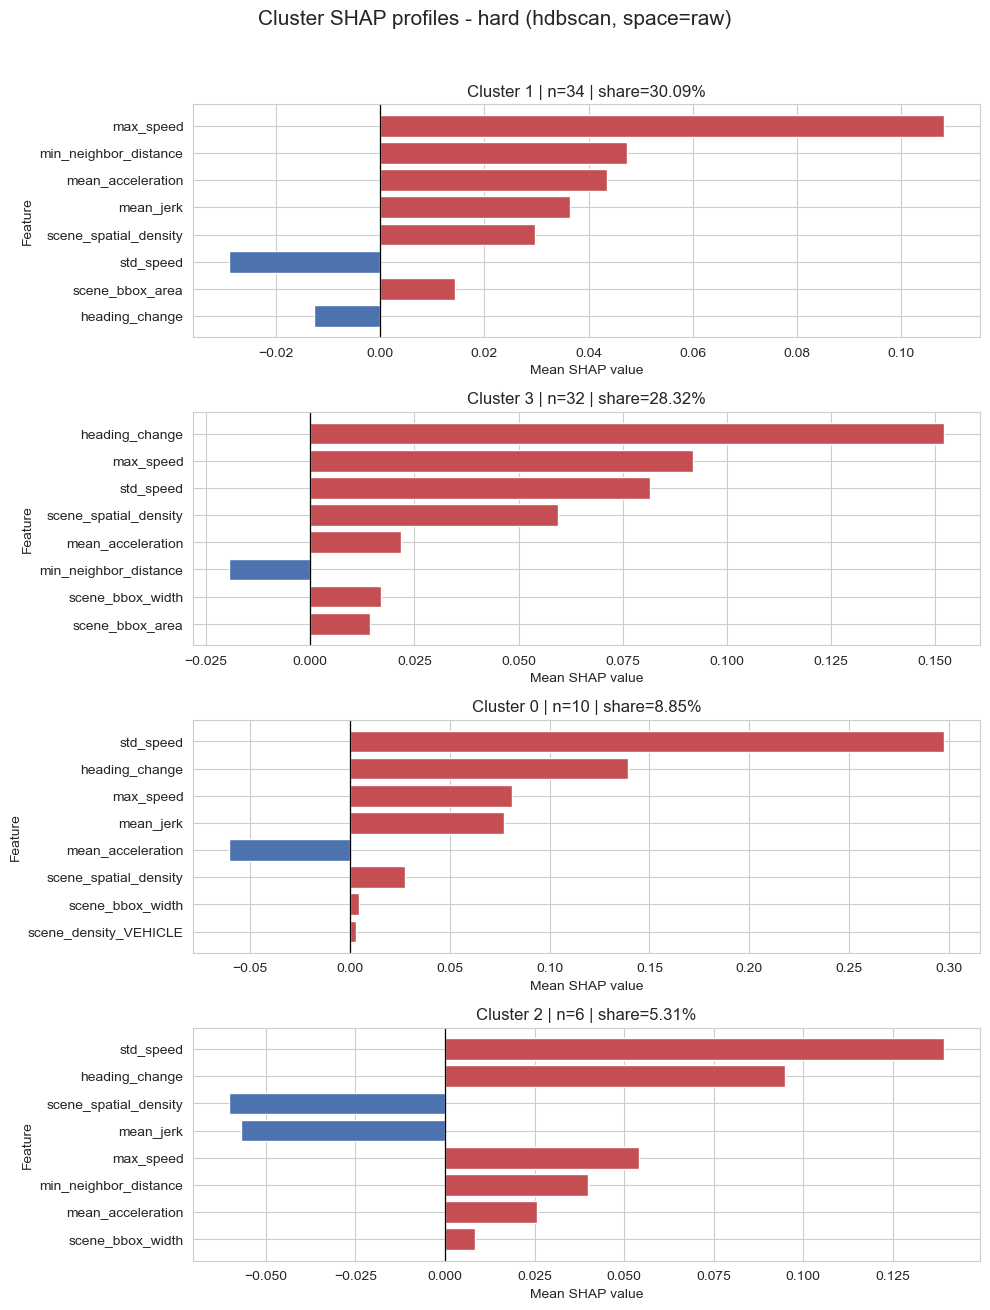

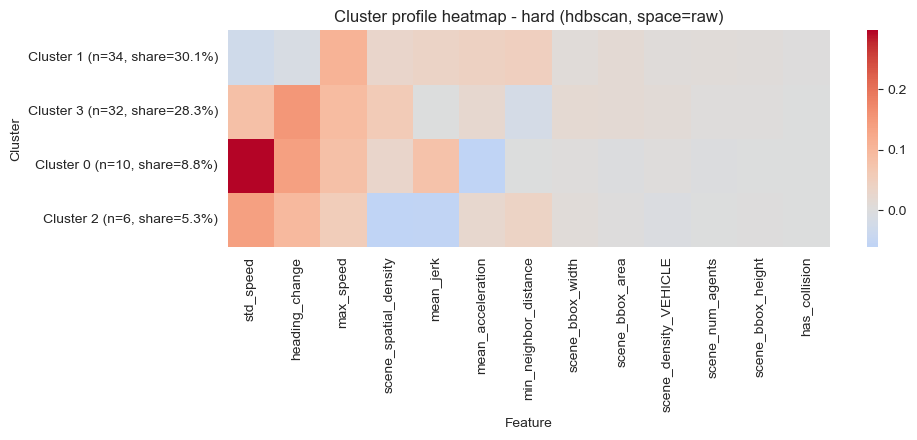

Inspection profile: medium


,performance_group,inspection_algorithm,inspection_cluster_space,dbcv_raw_shap_space,noise_fraction,n_clusters
0,medium,hdbscan,raw,0.029007,0.226667,2


,cluster_id,cluster_size,cluster_size_share,dominant_feature_1,dominant_direction_1,dominant_abs_shap_1,dominant_feature_2,dominant_direction_2,dominant_abs_shap_2,dominant_feature_3,dominant_direction_3,dominant_abs_shap_3
0,1,168,0.7467,max_speed,positive,0.0643,heading_change,negative,0.0560,std_speed,negative,0.0551
1,0,6,0.0267,max_speed,negative,0.0942,std_speed,negative,0.0748,scene_spatial_density,negative,0.0507


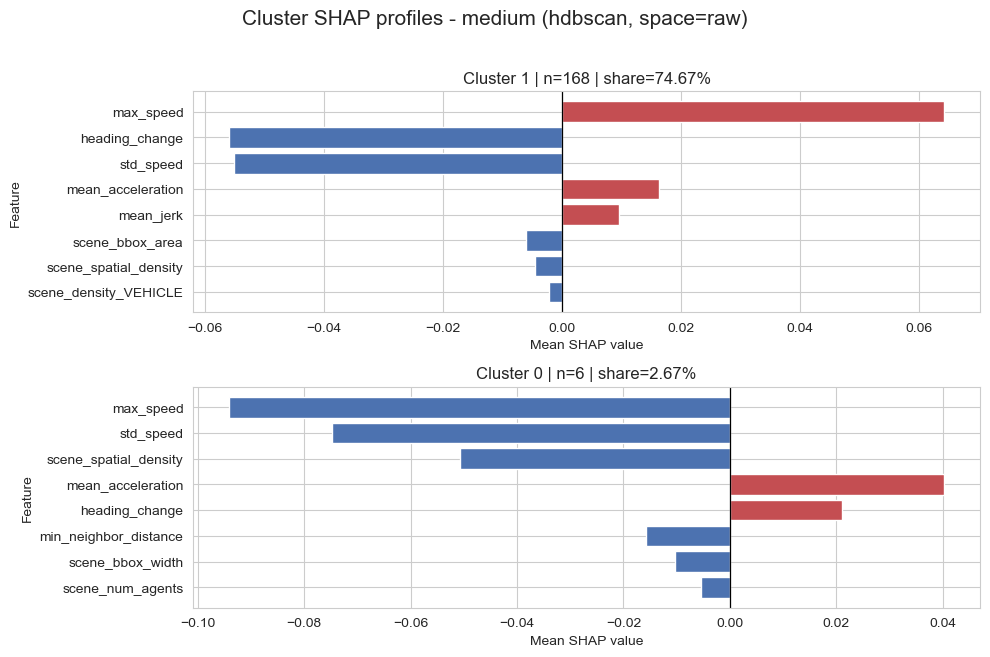

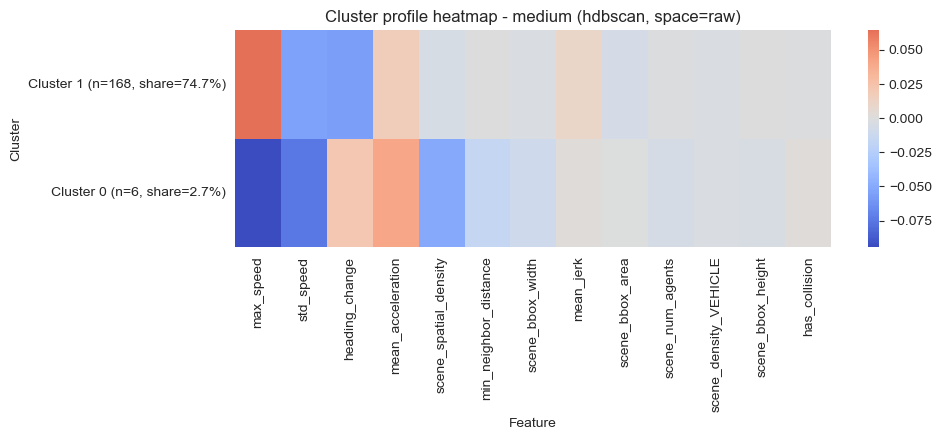

,artifact_kind,artifact_type,performance_group,relative_path,absolute_path,inspection_algorithm,inspection_cluster_space,inspection_top_k_features,inspection_top_k_table,sort_cluster_profiles_by
0,plot,cluster_profile_barplot,easy,plots/cluster_profile_barplot__group-easy__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hdbscan,raw,8,3,cluster_size
1,plot,cluster_profile_barplot,hard,plots/cluster_profile_barplot__group-hard__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hdbscan,raw,8,3,cluster_size
2,plot,cluster_profile_barplot,medium,plots/cluster_profile_barplot__group-medium__a...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hdbscan,raw,8,3,cluster_size


,artifact_kind,artifact_type,performance_group,relative_path,absolute_path,inspection_algorithm,inspection_cluster_space,inspection_top_k_features,inspection_top_k_table,sort_cluster_profiles_by
0,plot,cluster_profile_heatmap,easy,plots/cluster_profile_heatmap__group-easy__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hdbscan,raw,8,3,cluster_size
1,plot,cluster_profile_heatmap,hard,plots/cluster_profile_heatmap__group-hard__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hdbscan,raw,8,3,cluster_size
2,plot,cluster_profile_heatmap,medium,plots/cluster_profile_heatmap__group-medium__a...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hdbscan,raw,8,3,cluster_size


In [8]:
def build_top_driver_table(profile_df: pd.DataFrame, *, top_k_table: int) -> pd.DataFrame:
    top_driver_columns = ['cluster_id', 'cluster_size', 'cluster_size_share']
    for rank in range(1, top_k_table + 1):
        top_driver_columns.extend(
            [
                f'dominant_feature_{rank}',
                f'dominant_direction_{rank}',
                f'dominant_abs_shap_{rank}',
            ]
        )
    top_driver_df = profile_df[top_driver_columns].copy()
    top_driver_df['cluster_size_share'] = top_driver_df['cluster_size_share'].round(4)
    for rank in range(1, top_k_table + 1):
        top_driver_df[f'dominant_abs_shap_{rank}'] = top_driver_df[f'dominant_abs_shap_{rank}'].round(4)
    return top_driver_df


def plot_cluster_profile_barplots(
    profile_df: pd.DataFrame,
    *,
    performance_group: str,
    inspected_run: pd.Series,
    feature_label_lookup: dict[str, str],
    shap_cols: list[str],
    top_k_features: int,
    plot_path: Path,
) -> None:
    n_clusters = len(profile_df)
    fig, axes = plt.subplots(n_clusters, 1, figsize=(10, max(3.2 * n_clusters, 4.5)), squeeze=False)
    for axis_idx, (_, cluster_row) in enumerate(profile_df.iterrows()):
        ax = axes[axis_idx][0]
        top_shap_cols = sorted(
            shap_cols,
            key=lambda shap_col: abs(float(cluster_row[shap_col])),
            reverse=True,
        )[:top_k_features]
        top_shap_cols = list(reversed(top_shap_cols))
        values = [float(cluster_row[shap_col]) for shap_col in top_shap_cols]
        labels = [feature_label_lookup[shap_col] for shap_col in top_shap_cols]
        colors = ['#C44E52' if value > 0 else '#4C72B0' for value in values]
        ax.barh(labels, values, color=colors)
        ax.axvline(0, color='black', linewidth=0.9)
        ax.set_title(
            f"Cluster {int(cluster_row['cluster_id'])} | n={int(cluster_row['cluster_size'])} | share={cluster_row['cluster_size_share']:.2%}"
        )
        ax.set_xlabel('Mean SHAP value')
        ax.set_ylabel('Feature')
    fig.suptitle(
        f"Cluster SHAP profiles - {performance_group} ({inspected_run['algorithm']}, space={inspected_run['cluster_space']})",
        fontsize=15,
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


def plot_cluster_profile_heatmap(
    profile_df: pd.DataFrame,
    *,
    feature_label_lookup: dict[str, str],
    ordered_shap_cols: list[str],
    performance_group: str,
    inspected_run: pd.Series,
    plot_path: Path,
) -> None:
    heatmap_index = [
        f"Cluster {int(cluster_id)} (n={int(cluster_size)}, share={cluster_share:.1%})"
        for cluster_id, cluster_size, cluster_share in zip(
            profile_df['cluster_id'],
            profile_df['cluster_size'],
            profile_df['cluster_size_share'],
        )
    ]
    heatmap_plot_df = profile_df[ordered_shap_cols].copy()
    heatmap_plot_df.columns = [feature_label_lookup[shap_col] for shap_col in ordered_shap_cols]
    heatmap_plot_df.index = pd.Index(heatmap_index)

    fig, ax = plt.subplots(
        figsize=(max(10, len(ordered_shap_cols) * 0.55), max(4.5, len(profile_df) * 0.9))
    )
    sns.heatmap(
        heatmap_plot_df,
        cmap='coolwarm',
        center=0,
        ax=ax,
    )
    ax.set_title(
        f"Cluster profile heatmap - {performance_group} ({inspected_run['algorithm']}, space={inspected_run['cluster_space']})"
    )
    ax.set_xlabel('Feature')
    ax.set_ylabel('Cluster')
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)


barplot_manifest_records = []
heatmap_manifest_records = []
sort_key = INSPECTION_CONFIG_RESOLVED['sort_cluster_profiles_by']
inspection_metadata = {
    'inspection_algorithm': INSPECTION_CONFIG_RESOLVED['inspection_algorithm'],
    'inspection_cluster_space': INSPECTION_CONFIG_RESOLVED['inspection_cluster_space'],
    'inspection_top_k_features': INSPECTION_CONFIG_RESOLVED['inspection_top_k_features'],
    'inspection_top_k_table': INSPECTION_CONFIG_RESOLVED['inspection_top_k_table'],
    'sort_cluster_profiles_by': INSPECTION_CONFIG_RESOLVED['sort_cluster_profiles_by'],
}

for _, inspected_run in inspected_cluster_runs_df.sort_values('performance_group').iterrows():
    performance_group = inspected_run['performance_group']
    profile_df = cluster_shap_profiles_df.loc[
        cluster_shap_profiles_df['performance_group'] == performance_group
    ].copy()
    if profile_df.empty:
        continue

    ascending_flags = [False, True] if sort_key == 'cluster_size' else [True, True]
    profile_df = profile_df.sort_values([sort_key, 'cluster_id'], ascending=ascending_flags).reset_index(drop=True)
    # Order heatmap columns by average absolute cluster effect so the visually strongest
    # drivers appear first across the entire performance group.
    ordered_shap_cols = (
        profile_df[shap_cols]
        .abs()
        .mean(axis=0)
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    feature_label_lookup = {shap_col: format_shap_feature_name(shap_col) for shap_col in shap_cols}

    metadata_df = pd.DataFrame(
        [
            {
                'performance_group': performance_group,
                'inspection_algorithm': inspected_run['algorithm'],
                'inspection_cluster_space': inspected_run['cluster_space'],
                'dbcv_raw_shap_space': inspected_run['dbcv_raw_shap_space'],
                'noise_fraction': inspected_run['noise_fraction'],
                'n_clusters': inspected_run['n_clusters'],
            }
        ]
    )
    print(f'Inspection profile: {performance_group}')
    display(metadata_df)
    display(
        build_top_driver_table(
            profile_df,
            top_k_table=INSPECTION_CONFIG_RESOLVED['inspection_top_k_table'],
        )
    )

    barplot_path = PLOTS_DIR / ARTIFACT_NAMES['plots']['cluster_profile_barplots'][performance_group]
    plot_cluster_profile_barplots(
        profile_df,
        performance_group=performance_group,
        inspected_run=inspected_run,
        feature_label_lookup=feature_label_lookup,
        shap_cols=shap_cols,
        top_k_features=INSPECTION_CONFIG_RESOLVED['inspection_top_k_features'],
        plot_path=barplot_path,
    )

    heatmap_path = PLOTS_DIR / ARTIFACT_NAMES['plots']['cluster_profile_heatmaps'][performance_group]
    plot_cluster_profile_heatmap(
        profile_df,
        feature_label_lookup=feature_label_lookup,
        ordered_shap_cols=ordered_shap_cols,
        performance_group=performance_group,
        inspected_run=inspected_run,
        plot_path=heatmap_path,
    )

    barplot_manifest_records.append(
        {
            'artifact_kind': 'plot',
            'artifact_type': 'cluster_profile_barplot',
            'performance_group': performance_group,
            'relative_path': str(barplot_path.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
            'absolute_path': str(barplot_path.resolve()),
            **inspection_metadata,
        }
    )
    heatmap_manifest_records.append(
        {
            'artifact_kind': 'plot',
            'artifact_type': 'cluster_profile_heatmap',
            'performance_group': performance_group,
            'relative_path': str(heatmap_path.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
            'absolute_path': str(heatmap_path.resolve()),
            **inspection_metadata,
        }
    )

barplot_manifest_df = pd.DataFrame(barplot_manifest_records)
heatmap_manifest_df = pd.DataFrame(heatmap_manifest_records)
display(barplot_manifest_df)
display(heatmap_manifest_df)



## Export Regime Artifacts
**Purpose:** Persist the assembled regime table, clustering outputs, and selected cluster-profile plots for downstream interpretation.<br>
**Inputs:** The completed notebook dataframes plus the plot manifests accumulated in earlier sections.<br>
**Outputs:** CSV exports, saved plot files, and a final manifest table that records every generated plot path.<br>
**How to Verify:** Check that every printed output path exists under the run-specific results directory and that the plot manifest rows match the generated figures.


In [9]:
analysis_df.to_csv(REGIME_ANALYSIS_PATH, index=False)
group_summary_df.to_csv(PERFORMANCE_GROUP_SUMMARY_PATH, index=False)
trustworthiness_df.to_csv(UMAP_TRUSTWORTHINESS_PATH, index=False)
cluster_scores_df.to_csv(CLUSTER_SCORES_PATH, index=False)
clustered_df.to_csv(CLUSTER_ASSIGNMENTS_PATH, index=False)
cluster_shap_profiles_df.to_csv(CLUSTER_SHAP_PROFILES_PATH, index=False)

current_artifact_records = [
    {
        'artifact_kind': 'table',
        'artifact_type': 'regime_analysis',
        'relative_path': str(REGIME_ANALYSIS_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(REGIME_ANALYSIS_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'performance_group_summary',
        'relative_path': str(PERFORMANCE_GROUP_SUMMARY_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(PERFORMANCE_GROUP_SUMMARY_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'umap_trustworthiness',
        'relative_path': str(UMAP_TRUSTWORTHINESS_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(UMAP_TRUSTWORTHINESS_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'cluster_scores',
        'relative_path': str(CLUSTER_SCORES_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(CLUSTER_SCORES_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'cluster_assignments',
        'relative_path': str(CLUSTER_ASSIGNMENTS_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(CLUSTER_ASSIGNMENTS_PATH.resolve()),
    },
    {
        'artifact_kind': 'table',
        'artifact_type': 'cluster_shap_profiles',
        'relative_path': str(CLUSTER_SHAP_PROFILES_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(CLUSTER_SHAP_PROFILES_PATH.resolve()),
        'inspection_algorithm': INSPECTION_CONFIG_RESOLVED['inspection_algorithm'],
        'inspection_cluster_space': INSPECTION_CONFIG_RESOLVED['inspection_cluster_space'],
        'inspection_top_k_features': INSPECTION_CONFIG_RESOLVED['inspection_top_k_features'],
        'inspection_top_k_table': INSPECTION_CONFIG_RESOLVED['inspection_top_k_table'],
        'sort_cluster_profiles_by': INSPECTION_CONFIG_RESOLVED['sort_cluster_profiles_by'],
    },
    {
        'artifact_kind': 'plot',
        'artifact_type': 'raw_algorithm_comparison_grid',
        'relative_path': str(RAW_ALGORITHM_GRID_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
        'absolute_path': str(RAW_ALGORITHM_GRID_PATH.resolve()),
    },
]
if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    current_artifact_records.append(
        {
            'artifact_kind': 'plot',
            'artifact_type': 'umap_algorithm_comparison_grid',
            'relative_path': str(UMAP_ALGORITHM_GRID_PATH.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
            'absolute_path': str(UMAP_ALGORITHM_GRID_PATH.resolve()),
        }
    )
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    current_artifact_records.append(
        {
            'artifact_kind': 'plot',
            'artifact_type': 'umap_trustworthiness_curve',
            'trustworthiness_view': trustworthiness_view,
            'relative_path': str(plot_path.relative_to(EXPORT_LAYOUT['cluster_spec_root'])),
            'absolute_path': str(plot_path.resolve()),
        }
    )
current_artifact_records.extend(barplot_manifest_records)
current_artifact_records.extend(heatmap_manifest_records)

manifest_data = load_or_initialize_shap_regime_manifest(
    EXPORT_MANIFEST_PATH,
    run_context={
        'model_id': MODEL_ID,
        'run_name': RUN_NAME,
        'target_col': target_col,
        'eval_csv_name': EVAL_CSV_NAME,
        'run_manifest_path': str(run_ctx.manifest_path),
        'prepared_data_path': str(PREPARED_DATA_PATH),
        'shap_values_path': str(SHAP_VALUES_PATH),
        'joined_metrics_path': str(JOINED_METRICS_PATH),
    },
    data_context={
        'target_col': target_col,
        'eval_csv_name': EVAL_CSV_NAME,
        'lower_is_better': LOWER_IS_BETTER,
        'performance_group_col': PERFORMANCE_GROUP_COL,
        'data_context_slug': EXPORT_CONTEXT['data_context_slug'],
    },
    cluster_spec={
        'raw': CLUSTER_SPEC,
        'resolved': CLUSTER_SPEC_RESOLVED,
        'readable_slug': EXPORT_LAYOUT['cluster_spec_readable_slug'],
        'hash': EXPORT_LAYOUT['cluster_spec_hash'],
        'dirname': EXPORT_LAYOUT['cluster_spec_dirname'],
    },
)
manifest_data = merge_shap_regime_artifact_records(
    manifest_data,
    artifact_records=current_artifact_records,
)
EXPORT_MANIFEST_PATH.write_text(json.dumps(manifest_data, indent=2))
artifact_manifest_df = pd.DataFrame(manifest_data['artifacts'])

print('Saved artifacts:')
print(f'- Run manifest:               {run_ctx.manifest_path}')
print(f'- Prepared data export:       {PREPARED_DATA_PATH}')
print(f'- SHAP value export:          {SHAP_VALUES_PATH}')
print(f'- Joined metrics export:      {JOINED_METRICS_PATH}')
print(f'- Cluster-spec export root:   {EXPORT_LAYOUT["cluster_spec_root"]}')
print(f'- Export manifest:            {EXPORT_MANIFEST_PATH}')
print(f'- Regime analysis table:      {REGIME_ANALYSIS_PATH}')
print(f'- Performance group summary:  {PERFORMANCE_GROUP_SUMMARY_PATH}')
print(f'- UMAP trustworthiness:       {UMAP_TRUSTWORTHINESS_PATH}')
for trustworthiness_view, plot_path in UMAP_TRUSTWORTHINESS_PLOT_PATHS.items():
    print(f'- Trustworthiness curve ({trustworthiness_view}): {plot_path}')
print(f'- Cluster scores:             {CLUSTER_SCORES_PATH}')
print(f'- Cluster assignments:        {CLUSTER_ASSIGNMENTS_PATH}')
print(f'- Cluster SHAP profiles:      {CLUSTER_SHAP_PROFILES_PATH}')
print(
    '- Inspection selection:      '
    f"algorithm={INSPECTION_CONFIG_RESOLVED['inspection_algorithm']}, "
    f"space={INSPECTION_CONFIG_RESOLVED['inspection_cluster_space']}"
)
print(f'- Raw comparison grid:        {RAW_ALGORITHM_GRID_PATH}')
if CLUSTER_SPEC_RESOLVED['evaluate_umap_latent_space']:
    print(f'- Reduced comparison grid:    {UMAP_ALGORITHM_GRID_PATH}')
else:
    print("- Reduced comparison grid:    skipped (CLUSTER_SPEC['evaluate_umap_latent_space']=False)")
print(f'- Tables directory:           {TABLES_DIR}')
print(f'- Plot directory:             {PLOTS_DIR}')

display(artifact_manifest_df)



Saved artifacts:
- Run manifest:               /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/run_manifest_ml_ade_log.json
- Prepared data export:       ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
- SHAP value export:          /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/xgboost/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/tables/shap_values_ml_ade_log.csv
- Joined metrics export:      ../../results/trajectory_prediction/trajectory_metrics_joined/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/eval_epoch_5.csv
- Cluster-spec export root:   /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/interpretable_model/shap_performance_regimes/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/ml_ade_log/target-ml_ade_log__eval-eval_epoch_5.csv__lower-is-better-true__group-col-performance_g

,artifact_kind,artifact_type,relative_path,absolute_path,performance_group,inspection_algorithm,inspection_cluster_space,inspection_top_k_features,inspection_top_k_table,sort_cluster_profiles_by,trustworthiness_view
0,plot,raw_algorithm_comparison_grid,plots/algorithm_comparison_grid__space-raw.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,plot,umap_algorithm_comparison_grid,plots/algorithm_comparison_grid__space-umap.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,plot,cluster_profile_barplot,plots/cluster_profile_barplot__group-easy__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,easy,hdbscan,raw,8.0,3.0,cluster_size,NaN
3,plot,cluster_profile_barplot,plots/cluster_profile_barplot__group-hard__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hard,hdbscan,raw,8.0,3.0,cluster_size,NaN
4,plot,cluster_profile_barplot,plots/cluster_profile_barplot__group-medium__a...,/Users/simondrauz/Lokale Dokumente/Repositorie...,medium,hdbscan,raw,8.0,3.0,cluster_size,NaN
5,plot,cluster_profile_heatmap,plots/cluster_profile_heatmap__group-easy__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,easy,hdbscan,raw,8.0,3.0,cluster_size,NaN
6,plot,cluster_profile_heatmap,plots/cluster_profile_heatmap__group-hard__alg...,/Users/simondrauz/Lokale Dokumente/Repositorie...,hard,hdbscan,raw,8.0,3.0,cluster_size,NaN
7,plot,cluster_profile_heatmap,plots/cluster_profile_heatmap__group-medium__a...,/Users/simondrauz/Lokale Dokumente/Repositorie...,medium,hdbscan,raw,8.0,3.0,cluster_size,NaN
8,plot,umap_trustworthiness_curve,plots/umap_trustworthiness_curve__view-mean_5_...,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,mean_5_10_15
9,plot,umap_trustworthiness_curve,plots/umap_trustworthiness_curve__view-nn_10.png,/Users/simondrauz/Lokale Dokumente/Repositorie...,NaN,NaN,NaN,NaN,NaN,NaN,nn_10
